<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/aok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [ ]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [2]:
#NJ Office of GIS (Jan. 14, 2022), School Districts - Unified for NJ, 3424
#https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::school-districts-unified-for-nj-3424/about)
#unified school district shown in mp below was made with municipalities in mind
! wget -q -O nj-schools.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/School_Districts___Unified_7341673536716239500.zip

zip_ref = zipfile.ZipFile('nj-schools.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njSch=gpd.read_file('School_Districts_Unified.shp') #labeled shapefile njSch

<Axes: >

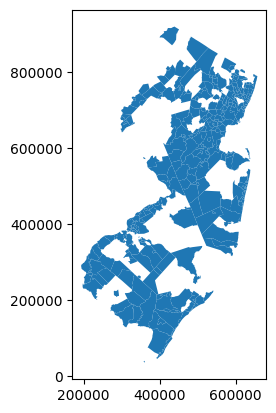

In [3]:
njSch.plot()

In [4]:
njSch.dtypes #School District Headings

,0
NJDOE_ID_U,object
DIST_NAME,object
UNSDLEA,object
SD_TYPE,object
GEOID,object
geometry,geometry


In [5]:
#change column names
njSch.rename(columns={'DIST_NAME' : 'District'}, inplace=True)

In [6]:
#make all upper case
njSch['District'] = njSch['District'].str.upper()

In [ ]:
njSch.dtypes

,0
NJDOE_ID_U,object
District,object
UNSDLEA,object
SD_TYPE,object
GEOID,object
geometry,geometry
c,object


In [7]:
EnrXls = pd.read_excel('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Camden%20County%20School%20Enrollment%20by%20School%20Level%202024%20-%20Public%20School%20Only.xlsx')

In [8]:
EnrXls.head(7)

,,"Audubon borough, Camden County, New Jersey","Audubon Park borough, Camden County, New Jersey","Barrington borough, Camden County, New Jersey","Bellmawr borough, Camden County, New Jersey","Berlin borough, Camden County, New Jersey","Berlin township, Camden County, New Jersey","Brooklawn borough, Camden County, New Jersey","Camden city, Camden County, New Jersey","Cherry Hill township, Camden County, New Jersey",...,"Pennsauken township, Camden County, New Jersey","Pine Hill borough, Camden County, New Jersey","Runnemede borough, Camden County, New Jersey","Somerdale borough, Camden County, New Jersey","Stratford borough, Camden County, New Jersey","Tavistock borough, Camden County, New Jersey","Voorhees township, Camden County, New Jersey","Waterford township, Camden County, New Jersey","Winslow township, Camden County, New Jersey","Woodlynne borough, Camden County, New Jersey"
0,Pre-School,90,0,11,128,26,26,4,987,332,...,298,250,100,93,32,0,67,199,118,10
1,K-8,767,50,277,1296,917,509,145,8628,7492,...,3725,855,601,366,673,2,3439,1029,3284,408
2,9-12,265,36,262,483,527,219,59,4221,2957,...,1869,463,326,168,301,0,1632,281,2049,204


In [ ]:
EnrXls = (EnrXls
  .rename(columns={EnrXls.columns[0]: 'School_Level'}) # Rename the first unnamed column
  .melt(
      id_vars=['School_Level'],
      var_name='District', # New column for district names
      value_name='Enrollment' # New column for enrollment values
  )
)

# Clean up district names (remove ', Camden County, New Jersey')
EnrXls['District'] = EnrXls['District'].str.replace(', Camden County, New Jersey', '', regex=False).str.strip()

# Convert 'Enrollment' to numeric, coercing errors to NaN
EnrXls['Enrollment'] = pd.to_numeric(EnrXls['Enrollment'], errors='coerce')

In [ ]:
EnrXls['District'] = EnrXls['District'].str.upper()

In [ ]:
EnrXls

,School_Level,District,Enrollment
0,Pre-School,AUDUBON BOROUGH,90
1,K-8,AUDUBON BOROUGH,767
2,9-12,AUDUBON BOROUGH,265
3,Pre-School,AUDUBON PARK BOROUGH,0
4,K-8,AUDUBON PARK BOROUGH,50
...,...,...,...
100,K-8,WINSLOW TOWNSHIP,3284
101,9-12,WINSLOW TOWNSHIP,2049
102,Pre-School,WOODLYNNE BOROUGH,10
103,K-8,WOODLYNNE BOROUGH,408


In [ ]:
njSch[['District','GEOID']]
DisXls1['c']=DisXls1.District.str.strip()
njSch['c']=njSch.District.str.strip()

,District,GEOID
0,WILLINGBORO PUBLIC SCHOOL DISTRICT,3418000
1,SOUTH RIVER PUBLIC SCHOOL DISTRICT,3415390
2,EAST BRUNSWICK TOWNSHIP SCHOOL DISTRICT,3404110
3,MONROE TOWNSHIP SCHOOL DISTRICT,3410500
4,DUMONT PUBLIC SCHOOL DISTRICT,3403990
...,...,...
334,COMMERCIAL TOWNSHIP SCHOOL DISTRICT,3403480
335,MAURICE RIVER TOWNSHIP SCHOOL DISTRICT,3409780
336,LACEY TOWNSHIP SCHOOL DISTRICT,3408100
337,OCEAN TOWNSHIP SCHOOL DISTRICT,3412090


In [ ]:
a2 = pd.merge(njSch, EnrXls, left_on=['District'], right_on=['District'], how='outer', indicator=True)
a2

,NJDOE_ID_U,District,UNSDLEA,SD_TYPE,GEOID,geometry,c,School_Level,Enrollment,_merge
0,01-0010,ABSECON PUBLIC SCHOOLS DISTRICT,00660,U,3400660,"POLYGON ((503391.012 215174.719, 503092.48 211...",ABSECON PUBLIC SCHOOLS DISTRICT,NaN,NaN,left_only
1,41-0030,ALLAMUCHY TOWNSHIP SCHOOL DISTRICT,00720,U,3400720,"POLYGON ((405096.281 772356.25, 406697.469 770...",ALLAMUCHY TOWNSHIP SCHOOL DISTRICT,NaN,NaN,left_only
2,25-0050,ALLENHURST SCHOOL DISTRICT,00780,U,3400780,"POLYGON ((633359.751 511841.852, 633367.748 51...",ALLENHURST SCHOOL DISTRICT,NaN,NaN,left_only
3,33-0060,ALLOWAY TWP SCHOOL DISTRICT,00810,U,3400810,"POLYGON ((270406.342 276106.935, 272736.652 27...",ALLOWAY TWP SCHOOL DISTRICT,NaN,NaN,left_only
4,41-0070,ALPHA BOROUGH SCHOOL DISTRICT,00840,U,3400840,"POLYGON ((311826.54 670255.46, 311866.85 67014...",ALPHA BOROUGH SCHOOL DISTRICT,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...
439,NaN,WOODLYNNE BOROUGH,NaN,NaN,NaN,None,NaN,Pre-School,10.0,right_only
440,NaN,WOODLYNNE BOROUGH,NaN,NaN,NaN,None,NaN,K-8,408.0,right_only
441,NaN,WOODLYNNE BOROUGH,NaN,NaN,NaN,None,NaN,9-12,204.0,right_only
442,07-5900,WOODLYNNE SCHOOL DISTRICT,18270,U,3418270,"POLYGON ((326156.607 396643.803, 326112.001 39...",WOODLYNNE SCHOOL DISTRICT,NaN,NaN,left_only


In [ ]:
a2._merge.value_counts()

,count
_merge,
left_only,339
right_only,105
both,0


<Axes: >

Text(0.5, 1.0, 'Total Students Enrolled in Public School\n2024 - 2025 School Year')

Text(0.35, 0.122, 'US Census: American Community Survey 5 Year\n            Downloaded Excel via:Shaperfile\n\n            ')

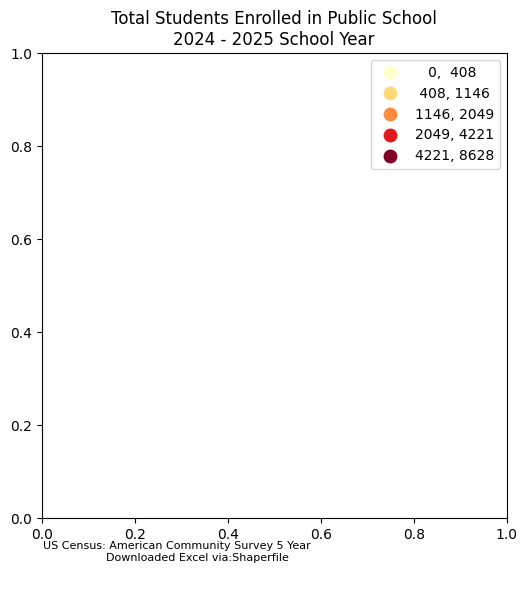

In [ ]:
fig, ax = plt.subplots(figsize=(6,8))

a2.plot(ax=ax,figsize=(6,8),column='Enrollment',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}"})
ax.set_title('''Total Students Enrolled in Public School
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''US Census: American Community Survey 5 Year
            Downloaded Excel via:Shaperfile

            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )